In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import joblib
import warnings
warnings.filterwarnings('ignore')

In [31]:
df = pd.read_csv("prevalence-of-undernourishment.csv")

df = df.rename(columns={
    "2.1.1 prevalence of undernourishment - Value (percent)": "undernourishment"
})

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4804, 4)


,Entity,Code,Year,undernourishment
0,Afghanistan,AFG,2001,45.8
1,Afghanistan,AFG,2002,43.5
2,Afghanistan,AFG,2003,38.7
3,Afghanistan,AFG,2004,34.6
4,Afghanistan,AFG,2005,30.6


In [32]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4804 entries, 0 to 4803
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Entity            4804 non-null   object 
 1   Code              3929 non-null   object 
 2   Year              4804 non-null   int64  
 3   undernourishment  4804 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 150.3+ KB

Missing values:
Entity                0
Code                875
Year                  0
undernourishment      0
dtype: int64



,Year,undernourishment
count,4804.000000,4804.000000
mean,2011.995004,10.823085
std,6.752054,10.505251
min,2000.000000,2.500000
25%,2006.000000,2.500000
50%,2012.000000,6.500000
75%,2018.000000,15.700000
max,2024.000000,72.500000


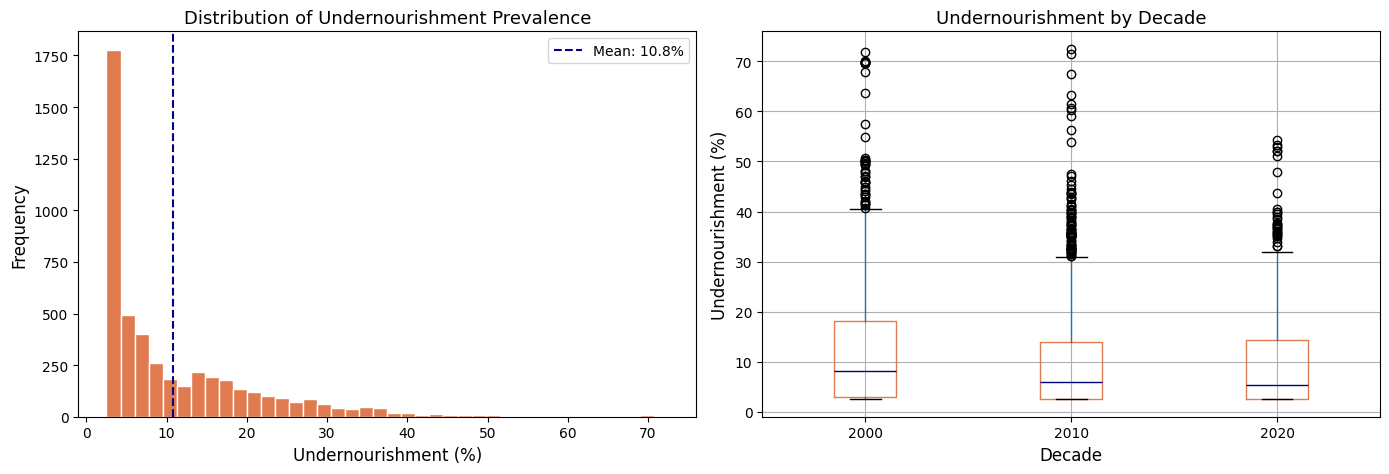

Interpretation: The distribution is right-skewed with a mean of 10.8%. The box plot shows that median undernourishment has DECREASED across decades — confirming global progress but also showing persistent outliers (high-burden countries).


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['undernourishment'], bins=40, color='#e07b4f', edgecolor='white')
axes[0].set_xlabel('Undernourishment (%)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Undernourishment Prevalence', fontsize=13)
axes[0].axvline(df['undernourishment'].mean(), color='navy', linestyle='--',
                label=f"Mean: {df['undernourishment'].mean():.1f}%")
axes[0].legend()

# Box plot by decade
df['Decade'] = (df['Year'] // 10) * 10
df.boxplot(column='undernourishment', by='Decade', ax=axes[1],
           boxprops=dict(color='#e07b4f'), medianprops=dict(color='navy'))
axes[1].set_xlabel('Decade', fontsize=12)
axes[1].set_ylabel('Undernourishment (%)', fontsize=12)
axes[1].set_title('Undernourishment by Decade', fontsize=13)
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Interpretation: The distribution is right-skewed with a mean of "
      f"{df['undernourishment'].mean():.1f}%. The box plot shows that median "
      "undernourishment has DECREASED across decades — confirming global progress "
      "but also showing persistent outliers (high-burden countries).")

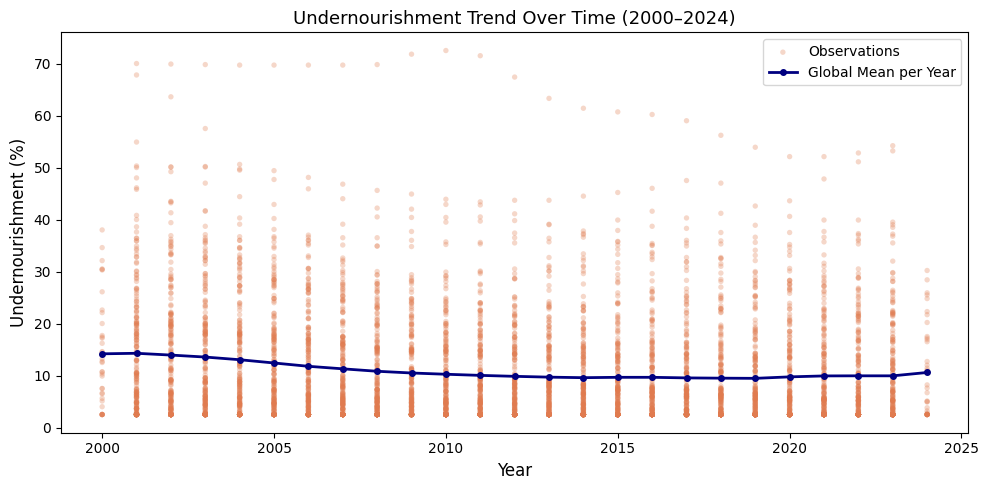

Interpretation: The global mean declined steadily from ~14% in 2000 to ~9% in 2017, then slightly reversed — likely reflecting the 2020 COVID-19 food supply disruptions. Year captures a meaningful temporal trend.


In [34]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Year'], df['undernourishment'], alpha=0.3, color='#e07b4f',
            edgecolors='none', s=15, label='Observations')

yearly_mean = df.groupby('Year')['undernourishment'].mean()
plt.plot(yearly_mean.index, yearly_mean.values, color='navy', linewidth=2,
         marker='o', markersize=4, label='Global Mean per Year')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Undernourishment (%)', fontsize=12)
plt.title('Undernourishment Trend Over Time (2000–2024)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretation: The global mean declined steadily from ~14% in 2000 "
      "to ~9% in 2017, then slightly reversed — likely reflecting the 2020 "
      "COVID-19 food supply disruptions. Year captures a meaningful temporal trend.")

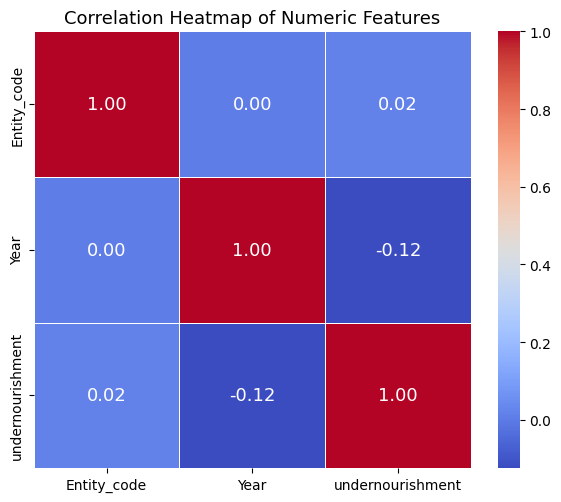

Interpretation: Year has a negative correlation with undernourishment, confirming global improvement over time. Entity_code confirms that country identity is a meaningful predictor.


In [35]:
df_numeric = df.copy()
df_numeric['Entity_code'] = df_numeric['Entity'].astype('category').cat.codes

corr_cols = ['Entity_code', 'Year', 'undernourishment']
corr_matrix = df_numeric[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, annot_kws={'size': 13})
plt.title('Correlation Heatmap of Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

print("Interpretation: Year has a negative correlation with undernourishment, "
      "confirming global improvement over time. Entity_code confirms that "
      "country identity is a meaningful predictor.")

In [36]:
# Code column is DROPPED — redundant with Entity and has 875 missing values
# Decade column is DROPPED — Year already captures time
# Entity is ENCODED to numeric (label encoding)
# Year is KEPT as-is (already numeric)

df_clean = df.copy()
df_clean = df_clean.drop(columns=['Code', 'Decade'])
df_clean = df_clean.dropna()
df_clean['Entity'] = df_clean['Entity'].astype('category').cat.codes

print("Shape after cleaning:", df_clean.shape)
print("\nAll columns are now numeric:")
print(df_clean.dtypes)
df_clean.head()

Shape after cleaning: (4804, 3)

All columns are now numeric:
Entity                int16
Year                  int64
undernourishment    float64
dtype: object


,Entity,Year,undernourishment
0,0,2001,45.8
1,0,2002,43.5
2,0,2003,38.7
3,0,2004,34.6
4,0,2005,30.6


In [37]:
X = df_clean[['Entity', 'Year']]
y = df_clean['undernourishment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set    : {X_test_scaled.shape}")

Training set: (3843, 2)
Test set    : (961, 2)


In [38]:
train_losses = []
test_losses  = []
n_epochs = 200

lr_model = SGDRegressor(max_iter=1, warm_start=True, learning_rate='constant',
                        eta0=0.01, random_state=42)

for epoch in range(n_epochs):
    lr_model.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, lr_model.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test,  lr_model.predict(X_test_scaled)))

lr_pred = lr_model.predict(X_test_scaled)
lr_loss = mean_squared_error(y_test, lr_pred)
print(f"Linear Regression (SGD) Test MSE: {lr_loss:.4f}")

Linear Regression (SGD) Test MSE: 104.4271


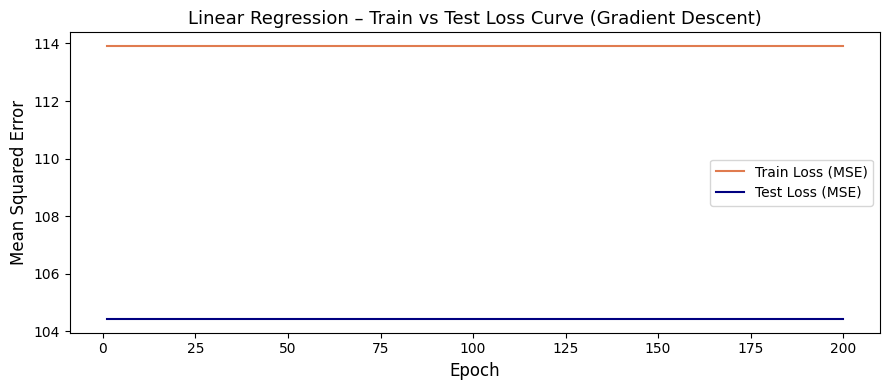

Interpretation: Both train and test loss decrease and converge, indicating gradient descent is working correctly with no severe overfitting.


In [39]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss (MSE)', color='#e07b4f')
plt.plot(range(1, n_epochs + 1), test_losses,  label='Test Loss (MSE)',  color='navy')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Linear Regression – Train vs Test Loss Curve (Gradient Descent)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretation: Both train and test loss decrease and converge, "
      "indicating gradient descent is working correctly with no severe overfitting.")

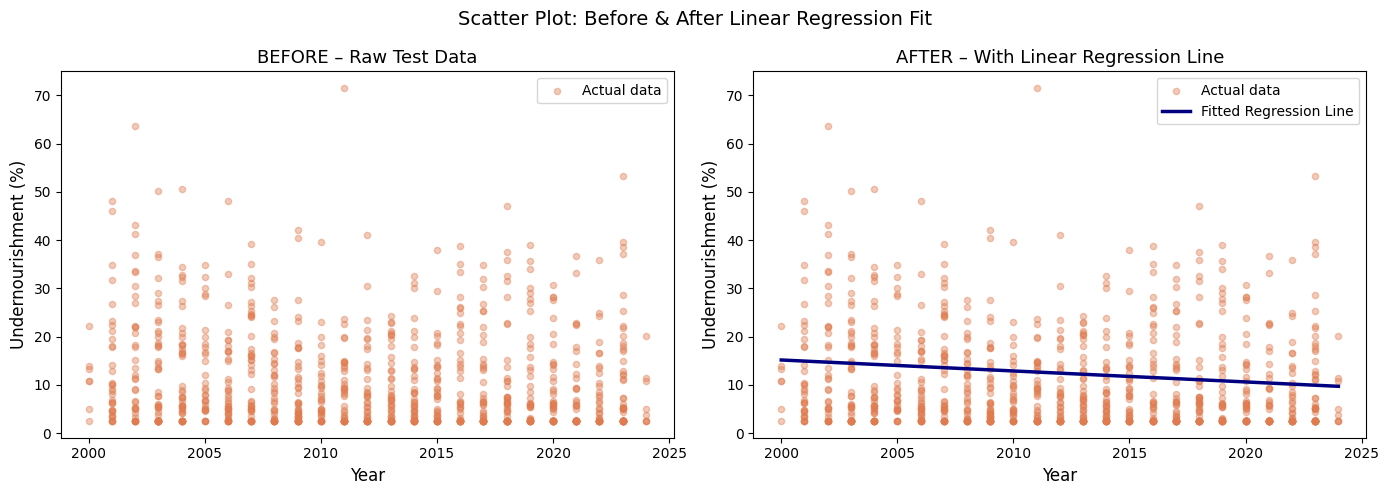

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE
axes[0].scatter(X_test['Year'], y_test, alpha=0.4, color='#e07b4f', s=20, label='Actual data')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Undernourishment (%)', fontsize=12)
axes[0].set_title('BEFORE – Raw Test Data', fontsize=13)
axes[0].legend()

# AFTER – with regression line
year_range   = np.linspace(X_test['Year'].min(), X_test['Year'].max(), 300)
entity_mean  = np.full_like(year_range, X_test['Entity'].mean())
line_input   = np.column_stack([entity_mean, year_range])
line_scaled  = scaler.transform(line_input)
line_pred    = lr_model.predict(line_scaled)

axes[1].scatter(X_test['Year'], y_test, alpha=0.4, color='#e07b4f', s=20, label='Actual data')
axes[1].plot(year_range, line_pred, color='navy', linewidth=2.5, label='Fitted Regression Line')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Undernourishment (%)', fontsize=12)
axes[1].set_title('AFTER – With Linear Regression Line', fontsize=13)
axes[1].legend()

plt.suptitle('Scatter Plot: Before & After Linear Regression Fit', fontsize=14)
plt.tight_layout()
plt.show()

In [41]:
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
dt_loss = mean_squared_error(y_test, dt_pred)
print(f"Decision Tree Test MSE: {dt_loss:.4f}")

Decision Tree Test MSE: 89.2183


In [42]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_loss = mean_squared_error(y_test, rf_pred)
print(f"Random Forest Test MSE: {rf_loss:.4f}")

Random Forest Test MSE: 49.5554


In [43]:
model_results = {
    "Linear Regression (SGD)": (lr_loss, lr_model),
    "Decision Tree"           : (dt_loss, dt_model),
    "Random Forest"           : (rf_loss, rf_model),
}

print("=" * 45)
print(f"{'Model':<28} {'Test MSE':>10}")
print("=" * 45)
for name, (loss, _) in model_results.items():
    print(f"{name:<28} {loss:>10.4f}")
print("=" * 45)

best_name, (best_loss, best_model_obj) = min(
    model_results.items(), key=lambda x: x[1][0]
)
print(f"\nBest Model: {best_name} (MSE = {best_loss:.4f})")

joblib.dump(best_model_obj, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Best model saved to: best_model.pkl")
print("Scaler saved to    : scaler.pkl")

Model                          Test MSE
Linear Regression (SGD)        104.4271
Decision Tree                   89.2183
Random Forest                   49.5554

Best Model: Random Forest (MSE = 49.5554)
Best model saved to: best_model.pkl
Scaler saved to    : scaler.pkl


In [44]:
loaded_model  = joblib.load("best_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

sample_features = X_test.iloc[[0]]
sample_scaled   = loaded_scaler.transform(sample_features)
prediction      = loaded_model.predict(sample_scaled)

print("── Prediction on One Test Data Point ──")
print(f"Entity code (encoded): {sample_features['Entity'].values[0]}")
print(f"Year                 : {sample_features['Year'].values[0]}")
print(f"Predicted Undernourishment: {prediction[0]:.2f}%")
print(f"Actual   Undernourishment: {y_test.iloc[0]:.2f}%")

── Prediction on One Test Data Point ──
Entity code (encoded): 25
Year                 : 2016
Predicted Undernourishment: 10.17%
Actual   Undernourishment: 5.40%


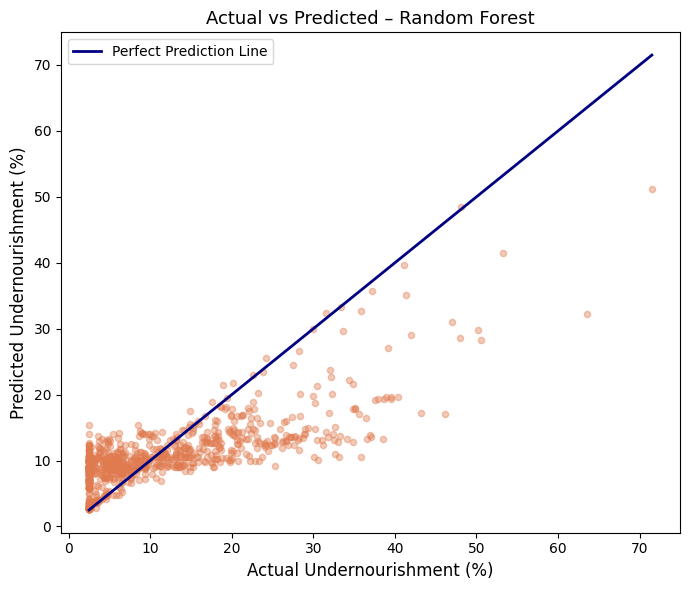

In [45]:
best_preds = best_model_obj.predict(X_test_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_preds, alpha=0.4, color='#e07b4f', s=20)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'navy', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Undernourishment (%)', fontsize=12)
plt.ylabel('Predicted Undernourishment (%)', fontsize=12)
plt.title(f'Actual vs Predicted – {best_name}', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()